# Análise de Dados: Fatores de Influência no Mercado de Vinhos 
## Como o preço e a avaliação influenciam a preferência dos consumidores por vinhos?
## Quais fatores influenciam a decisão de compra de vinho pelos consumidores?



O presente trabalho tem como objetivo analisar dados relacionados ao consumo e avaliação de vinhos, buscando identificar os principais fatores que influenciam a percepção de qualidade pelos consumidores. A análise foi realizada a partir de um conjunto de dados, o dataset Wine Reviews(Kaggle), contendo informações como preço, pontuação, país de origem e características dos vinhos.
A relevância deste estudo está na compreensão do comportamento do consumidor, especialmente no que diz respeito à relação entre preço e qualidade percebida, auxiliando na tomada de decisão de compra.


In [2]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/zynicide/wine-reviews/winemag-data-130k-v2.csv")
df

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129966,129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Anna Lee C. Iijima,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


### Metodologia

Foi utilizado um dataset contendo 130 mil avaliações de vinhos, com as seguintes etapas


- Remoção de valores nulos nas colunas relevantes (price, points, country, title) 
- Organização e filtragem dos dados 
- Agrupamento por país para análise comparativa 
- Ordenação dos dados para identificação dos melhores vinhos 
- Criação de gráficos para visualização dos resultados
   
As análises foram realizadas utilizando Python, com apoio das bibliotecas Pandas e Matplotlib.


In [3]:
# Os 20 Vinhos mais caros e sua pontuação

df_limpo = df.dropna(subset=['price', 'title', 'points','country'])
df_resul = df_limpo [['title', 'price', 'points']].sort_values(
    by='price',
    ascending = False
).head(20)
print(df_resul)

                                                    title   price  points
80290                Château les Ormes Sorbet 2013  Médoc  3300.0      88
15840                        Château Pétrus 2014  Pomerol  2500.0      96
98380      Domaine du Comte Liger-Belair 2010  La Romanée  2500.0      96
120391  Blair 2013 Roger Rose Vineyard Chardonnay (Arr...  2013.0      91
113564     Domaine du Comte Liger-Belair 2005  La Romanée  2000.0      96
65352                        Château Pétrus 2011  Pomerol  2000.0      97
1558                        Château Margaux 2009  Margaux  1900.0      98
111755           Château Cheval Blanc 2010  Saint-Émilion  1500.0     100
111753           Château Lafite Rothschild 2010  Pauillac  1500.0     100
1575             Château Mouton Rothschild 2009  Pauillac  1300.0      96
1571              Château Haut-Brion 2009  Pessac-Léognan  1200.0      96
113581     Domaine du Comte Liger-Belair 2006  La Romanée  1125.0      94
89478   Emmerich Knoll 2013 Ried Loibe

In [4]:
# Encontrado um outlier nos dados
#O vinho Château les Ormes Sorbet está com erro na digitaçao do preço, o que pode interferir na analise
df = df[~df['title'].str.contains("Ormes Sorbet", na=False)]

### Relação entre preço e qualidade

Ao analisar os dados, observa-se que o vinho mais caro da amostra, Château Pétrus 2014 Pomerol, com valor de aproximadamente $2.500,00, não apresentou a pontuação máxima, obtendo nota 96.

Esse resultado reforça que preços elevados não garantem, necessariamente, a melhor avaliação. Embora vinhos mais caros frequentemente estejam associados à alta qualidade, outros fatores — como características sensoriais, safra e preferência dos avaliadores — também influenciam a pontuação final.

In [5]:
# Pontuação dos vinhos e dos preços na ordem decrescente 

df_points = df_limpo[['title', 'points', 'price']]. sort_values(
    by= ['points', 'price'],
    ascending = [False, False]
).head(20)
print(df_points)

                                                    title  points   price
111753           Château Lafite Rothschild 2010  Pauillac     100  1500.0
111755           Château Cheval Blanc 2010  Saint-Émilion     100  1500.0
122935            Château Haut-Brion 2014  Pessac-Léognan     100   848.0
114972      Quinta do Noval 2011 Nacional Vintage  (Port)     100   650.0
89729   Salon 2006 Le Mesnil Blanc de Blancs Brut Char...     100   617.0
45781   Biondi Santi 2010 Riserva  (Brunello di Montal...     100   550.0
39286   Tenuta dell'Ornellaia 2007 Masseto Merlot (Tos...     100   460.0
42197       Casa Ferreirinha 2008 Barca-Velha Red (Douro)     100   450.0
118058            Verité 2007 La Muse Red (Sonoma County)     100   450.0
111756      Château Léoville Las Cases 2010  Saint-Julien     100   359.0
345     Chambers Rosewood Vineyards NV Rare Muscat (Ru...     100   350.0
111754  Casanova di Neri 2007 Cerretalto  (Brunello di...     100   270.0
36528                         Krug 200

A análise dos dados indica que não é necessário pagar os preços mais elevados para consumir vinhos de alta qualidade. Observa-se que rótulos como Charles Smith 2006 Royal City Syrah (Columbia Valley) e Cayuse 2008 Bionic Frog Syrah (Walla Walla Valley) alcançaram a pontuação máxima (100 pontos), mesmo apresentando um preço de aproximadamente $80,00.

Esse resultado sugere que, embora exista uma tendência de vinhos mais caros apresentarem boas avaliações, o preço não é o único fator determinante da qualidade. Dessa forma, consumidores podem encontrar vinhos de excelência em faixas de preço intermediárias, o que reforça a importância de considerar outros critérios além do valor na decisão de compra.

In [6]:
#Vinhos com melhores pontuações, em ordem decrescente mostrando toda o DF
df = df.dropna (subset=['points'])
df_points = df.sort_values(
    by=['points'],
    ascending=[False]
).head(10)
print(df_points)

        Unnamed: 0    country  \
7335          7335      Italy   
39286        39286      Italy   
36528        36528     France   
345            345  Australia   
123545      123545         US   
111753      111753     France   
45798        45798         US   
122935      122935     France   
89728        89728     France   
118058      118058         US   

                                              description  \
7335    Thick as molasses and dark as caramelized brow...   
39286   A perfect wine from a classic vintage, the 200...   
36528   This is a fabulous wine from the greatest Cham...   
345     This wine contains some material over 100 year...   
123545  Initially a rather subdued Frog; as if it has ...   
111753  Almost black in color, this stunning wine is g...   
45798   Tasted in a flight of great and famous Napa wi...   
122935  Full of ripe fruit, opulent and concentrated, ...   
89728   This latest incarnation of the famous brand is...   
118058  This wine dazzles 

### Análise por país

A análise do ranking de países com volume relevante de vinhos (mais de 100 registros) mostrou que:


- Países como Áustria, Alemanha e Canadá apresentam as maiores pontuações médias; 
- Países tradicionais como França e Itália possuem preços médios elevados, mas não lideram em pontuação; 
- Países como Chile, Argentina e Portugal oferecem vinhos com preços mais baixos e boa avaliação.
 
Esses resultados indicam que a qualidade dos vinhos está distribuída entre diferentes regiões, não sendo exclusiva de países mais tradicionais ou com maior custo.


In [7]:
#Vinhos com maiores pontuações e região
df_country = df_limpo[['title','country','points']].sort_values(
    by = ['points'],
    ascending = [False]
).head(20)
print(df_country)

                                                    title    country  points
45781   Biondi Santi 2010 Riserva  (Brunello di Montal...      Italy     100
45798     Cardinale 2006 Cabernet Sauvignon (Napa Valley)         US     100
345     Chambers Rosewood Vineyards NV Rare Muscat (Ru...  Australia     100
113929  Charles Smith 2006 Royal City Syrah (Columbia ...         US     100
118058            Verité 2007 La Muse Red (Sonoma County)         US     100
58352          Château Léoville Barton 2010  Saint-Julien     France     100
122935            Château Haut-Brion 2014  Pessac-Léognan     France     100
114972      Quinta do Noval 2011 Nacional Vintage  (Port)   Portugal     100
7335    Avignonesi 1995 Occhio di Pernice  (Vin Santo ...      Italy     100
111756      Château Léoville Las Cases 2010  Saint-Julien     France     100
111755           Château Cheval Blanc 2010  Saint-Émilion     France     100
111754  Casanova di Neri 2007 Cerretalto  (Brunello di...      Italy     100

In [8]:
#Ordenar os paises com melhores pontuações
#Os dados mostram que a Inglaterra apresenta a maior pontuação

df_ranking_paises = (df.groupby("country")["points"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .head(10))
                        
print(df_ranking_paises)

      country     points
0     England  91.581081
1       India  90.222222
2     Austria  90.101345
3     Germany  89.851732
4      Canada  89.369650
5     Hungary  89.191781
6       China  89.000000
7      France  88.845360
8  Luxembourg  88.666667
9   Australia  88.580507


In [9]:
#Ordenar por preço e por país

df = df.dropna(subset=["price"])
df_preco_pais = df.groupby('country')['price'].mean().reset_index()
df_preco_pais = df_preco_pais.sort_values(by = 'price', ascending=False).head(20)

print(df_preco_pais[['country', 'price']].round(2).to_string(index=False))

     country  price
 Switzerland  85.29
     England  51.68
     Germany  42.26
      France  40.96
     Hungary  40.65
       Italy  39.66
          US  36.57
      Canada  35.71
   Australia  35.44
      Israel  31.77
     Austria  30.76
     Lebanon  30.69
       Spain  28.22
 New Zealand  26.93
      Mexico  26.79
     Uruguay  26.40
    Portugal  26.22
     Croatia  25.45
    Slovenia  24.81
South Africa  24.67


In [10]:
#Média - Ordenada por nome e preço

df_preco = (df.groupby('title')['price']
            .mean()
            .sort_values(ascending = False)
            .reset_index()
            .head(10))
print(df_preco)

                                               title   price
0     Domaine du Comte Liger-Belair 2010  La Romanée  2500.0
1                       Château Pétrus 2014  Pomerol  2500.0
2  Blair 2013 Roger Rose Vineyard Chardonnay (Arr...  2013.0
3     Domaine du Comte Liger-Belair 2005  La Romanée  2000.0
4                       Château Pétrus 2011  Pomerol  2000.0
5                      Château Margaux 2009  Margaux  1900.0
6           Château Cheval Blanc 2010  Saint-Émilion  1500.0
7           Château Lafite Rothschild 2010  Pauillac  1500.0
8           Château Mouton Rothschild 2009  Pauillac  1300.0
9     Domaine du Comte Liger-Belair 2006  La Romanée  1125.0


In [11]:
#Os 10 melhores vinhos classificados pelos preços e pontuação
df= df.dropna(subset = ['title','points','price'])
top10 = df.sort_values(
    by=["points", "price", "title"],
    ascending=[False, False, True]
).head(20)

print(top10[["title", "country", "price", "points"]].to_string(index=False))


                                                           title   country  price  points
                        Château Cheval Blanc 2010  Saint-Émilion    France 1500.0     100
                        Château Lafite Rothschild 2010  Pauillac    France 1500.0     100
                         Château Haut-Brion 2014  Pessac-Léognan    France  848.0     100
                   Quinta do Noval 2011 Nacional Vintage  (Port)  Portugal  650.0     100
Salon 2006 Le Mesnil Blanc de Blancs Brut Chardonnay (Champagne)    France  617.0     100
             Biondi Santi 2010 Riserva  (Brunello di Montalcino)     Italy  550.0     100
             Tenuta dell'Ornellaia 2007 Masseto Merlot (Toscana)     Italy  460.0     100
                   Casa Ferreirinha 2008 Barca-Velha Red (Douro)  Portugal  450.0     100
                         Verité 2007 La Muse Red (Sonoma County)        US  450.0     100
                   Château Léoville Las Cases 2010  Saint-Julien    France  359.0     100
         C

In [12]:
df_ranking_paises = df.groupby("country")["points"].mean().reset_index()
df_preco_pais = df.groupby('country')['price'].mean().reset_index()

df_final = pd.merge(df_ranking_paises, df_preco_pais, on='country')
df_final = df_final.sort_values(by='points', ascending = False).head(10)

print(df_final[['country', 'points','price']].round(2).to_string(index=False))


   country  points  price
   England   91.55  51.68
     India   90.22  13.33
   Austria   90.19  30.76
   Germany   89.84  42.26
    Canada   89.38  35.71
   Hungary   89.17  40.65
     China   89.00  18.00
    France   88.73  40.96
Luxembourg   88.67  23.33
     Italy   88.62  39.66


In [13]:
# 1. Criar a contagem de vinhos por país
# Apos identificar que a Inglaterra aparece no topo dos paises mais bem avaliados, infere-se que pode haver um vies do volume relevante de vinhos  
contagem = df['country'].value_counts()

# 2. Filtrar países com mais de 100 avaliações
paises_relevantes= contagem[contagem>100].index

df_filtrado = df[df['country'].isin(paises_relevantes)]

df_ranking_paises = df_filtrado.groupby("country")["points"].mean().reset_index()
df_preco_pais = df_filtrado.groupby('country')['price'].mean().reset_index()

df_final = pd.merge(df_ranking_paises, df_preco_pais, on='country')
df_final = df_final.sort_values(by='points', ascending=False).head(20)

print("--- Ranking de Países com Volume Relevante (>100 vinhos) ---")
print(df_final[['country', 'points', 'price']].round(2).to_string(index=False))

--- Ranking de Países com Volume Relevante (>100 vinhos) ---
     country  points  price
     Austria   90.19  30.76
     Germany   89.84  42.26
      Canada   89.38  35.71
     Hungary   89.17  40.65
      France   88.73  40.96
       Italy   88.62  39.66
   Australia   88.60  35.44
          US   88.57  36.57
      Israel   88.50  31.77
    Portugal   88.32  26.22
 New Zealand   88.31  26.93
    Bulgaria   87.94  14.65
South Africa   87.83  24.67
       Spain   87.29  28.22
      Greece   87.29  22.36
     Uruguay   86.75  26.40
   Argentina   86.71  24.51
       Chile   86.50  20.79
     Romania   86.40  15.24


A análise do ranking de países com volume relevante de vinhos (mais de 100 registros) revela diferenças importantes na relação entre preço médio e avaliação (pontuação). Países como Áustria, Alemanha e Canadá lideram o ranking em termos de pontuação média, com notas próximas ou superiores a 89 pontos, mesmo apresentando preços médios moderados.

Por outro lado, observa-se que países tradicionalmente reconhecidos, como França e Itália, apresentam preços médios mais elevados (acima de $39), mas não lideram o ranking de pontuação. Isso indica que, embora esses países tenham forte reputação no mercado, o preço mais alto não necessariamente se traduz em melhor avaliação média.

Além disso, países como Portugal, Chile e Argentina se destacam por oferecer vinhos com preços mais acessíveis e avaliações relativamente próximas das maiores pontuações, sugerindo uma melhor relação custo-benefício. Por exemplo, o Chile apresenta um dos menores preços médios ($20,79), mantendo uma pontuação média competitiva (86,50).

Esses resultados reforçam que a relação entre preço e qualidade não é linear. Consumidores podem encontrar vinhos bem avaliados em diferentes faixas de preço e origens, o que evidencia que fatores como região, técnicas de produção e preferências dos avaliadores também influenciam significativamente a percepção de qualidade.

In [18]:
df_group = df.groupby("country")[["points", "price"]].mean().reset_index()
print(df_group.head())

                  country     points      price
0               Argentina  86.710330  24.510117
1                 Armenia  87.500000  14.500000
2               Australia  88.595466  35.437663
3                 Austria  90.190782  30.762772
4  Bosnia and Herzegovina  86.500000  12.500000


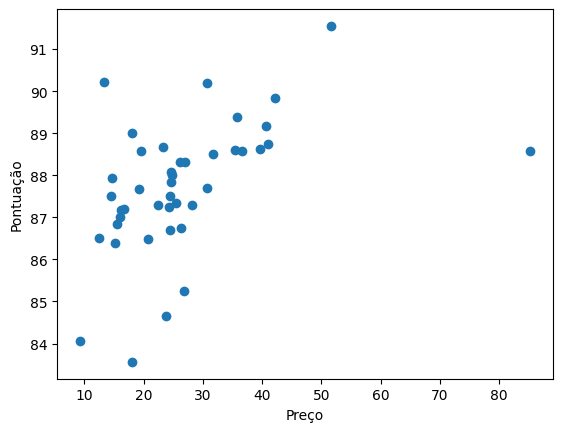

In [21]:
#gráfico de dispersão (scatter plot) — para comparar preço vs pontuação.
# Chatgpt
import matplotlib.pyplot as plt
plt.figure()

plt.scatter(df_group["price"], df_group["points"])

plt.xlabel("Preço")
plt.ylabel("Pontuação")

plt.savefig("grafico_real.png", dpi=300, bbox_inches='tight')

plt.show()

In [17]:
# Lista todas as variáveis do tipo DataFrame que estão na memória atual
%whos DataFrame

Variable            Type         Data/Info
------------------------------------------
df                  DataFrame            Unnamed: 0   coun<...>120974 rows x 14 columns]
df_country          DataFrame                             <...>alley)         US      99
df_filtrado         DataFrame            Unnamed: 0   coun<...>120177 rows x 14 columns]
df_final            DataFrame             country     poin<...>nia  86.400000  15.241667
df_limpo            DataFrame            Unnamed: 0   coun<...>120916 rows x 14 columns]
df_points           DataFrame            Unnamed: 0    cou<...>                 Verité  
df_preco            DataFrame                             <...> 2006  La Romanée  1125.0
df_preco_pais       DataFrame             country      pri<...>       Uruguay  26.403670
df_ranking_paises   DataFrame             country     poin<...>       Uruguay  86.752294
df_resul            DataFrame                             <...>Montal...   900.0      94
top10               Data

### Identificando os vinhos da região do Brasil


In [22]:
# Mostrar os vinhos mais bem avaliados da região do Brasil, como tambem o preço e a pontuação

df = df.dropna(subset = ['country', 'price', 'points'])
vinhos_brasil = df[df["country"] == "Brazil"]

vinhos_brasil = vinhos_brasil.sort_values(
    by = ['points', 'price', 'title'],
    ascending = [False, False, True]
).head(20)

print(vinhos_brasil[["title", "country", "price", "points"]].to_string(index=False))




                                                            title country  price  points
Cave Geisse 2012 Blanc de Blancs Brut Chardonnay (Pinto Bandeira)  Brazil   45.0      89
          Cave Geisse 2013 Brut Nature Sparkling (Pinto Bandeira)  Brazil   36.0      89
                 Cave Geisse 2014 Brut Sparkling (Pinto Bandeira)  Brazil   36.0      88
                               Casa Valduga NV 130 Brut  (Brazil)  Brazil   33.0      88
                          Casa Perini NV Moscatel (Vale Trentino)  Brazil   20.0      88
             Lidio Carraro 2013 Dádivas Chardonnay (Serra Gaúcha)  Brazil   20.0      88
                   Lidio Carraro 2011 Agnus Merlot (Serra Gaúcha)  Brazil   15.0      88
 Cave Geisse NV Cave Amadeu Rosé Brut Pinot Noir (Pinto Bandeira)  Brazil   25.0      87
                                 Salton 2009 Talento Red (Brazil)  Brazil   21.0      87
       Casa Perini NV Charmat Brut Rosé Sparkling (Vale Trentino)  Brazil   20.0      87
                     

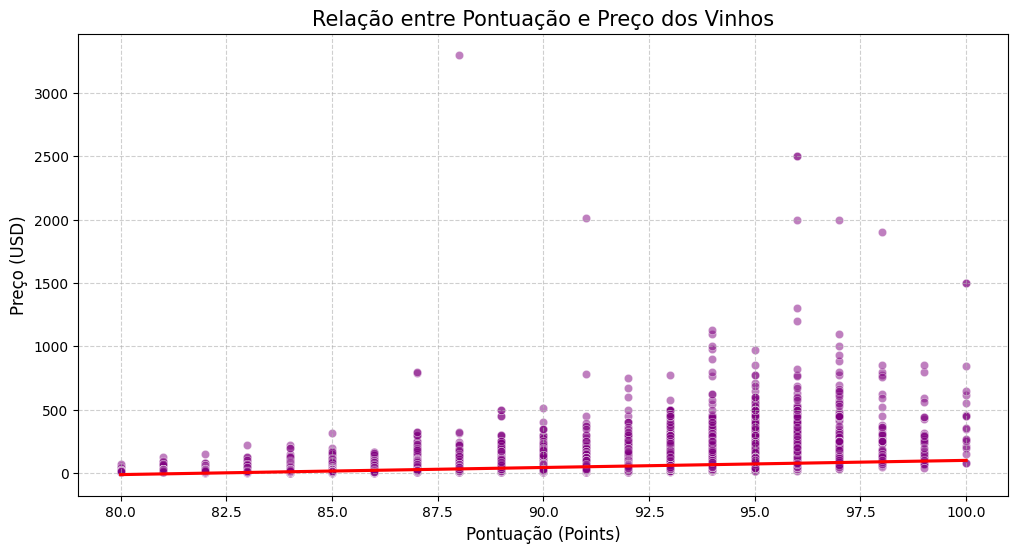

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_limpo, x='points', y='price', alpha=0.5, color='purple')

# Adicionando uma linha de tendência para mostrar a correlação
sns.regplot(data=df_limpo, x='points', y='price', scatter=False, color='red')

plt.title('Relação entre Pontuação e Preço dos Vinhos', fontsize=15)
plt.xlabel('Pontuação (Points)', fontsize=12)
plt.ylabel('Preço (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_55/424488186.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final, x='points', y='country', palette='viridis')


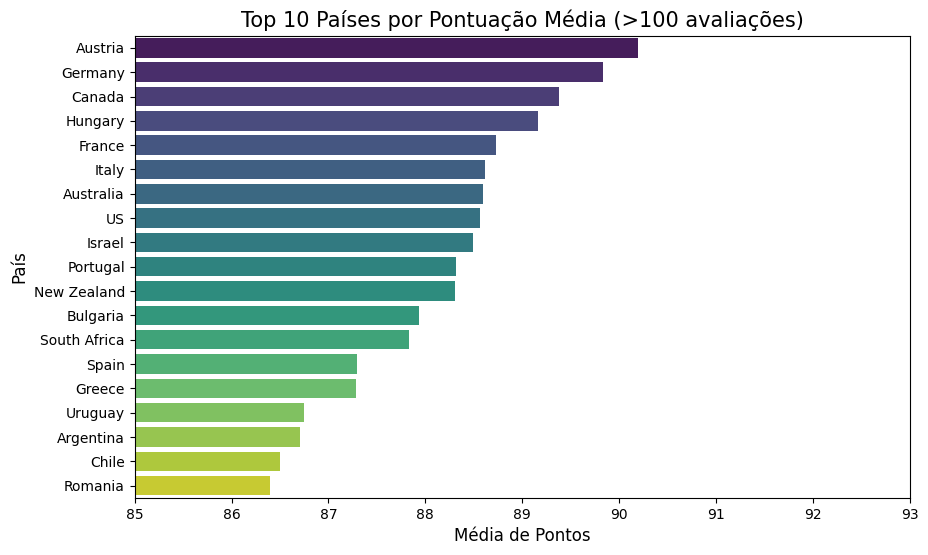

<Figure size 640x480 with 0 Axes>

In [24]:
# Gráfico de barras horizontais estilizado com auxílio do Google Gemini 
# para otimização da hierarquia visual e formatação de rótulos.
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(data=df_final, x='points', y='country', palette='viridis')

# Ajustando o eixo X para focar na diferença (notas de 85 a 93)
plt.xlim(85, 93)

plt.title('Top 10 Países por Pontuação Média (>100 avaliações)', fontsize=15)
plt.xlabel('Média de Pontos', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.show()
plt.savefig('meu_grafico_top10.png', dpi=300, bbox_inches='tight')

# 2. MOSTRAR depois
plt.savefig("grafico_real1.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
plt.savefig("grafico_real.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
# Gráfico de barras horizontais estilizado com auxílio do Google Gemini 
# para otimização da hierarquia visual e formatação de rótulos.

import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo do Seaborn
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

# Criando o gráfico com uma paleta de cores degradê (opcional)
# 'rocket' ou 'viridis' dão um ar bem profissional
barplot = sns.barplot(
    x="points", 
    y="title", 
    data=top10, 
    palette="flare",
    hue="title", # Diferencia as cores por título
    legend=False
)

# Adicionando os rótulos de texto com um leve deslocamento (offset)
for i, (pontos, preco) in enumerate(zip(top10["points"], top10["price"])):
    # Colocamos o texto um pouco à frente do final da barra
    plt.text(
        pontos + 0.1, i, 
        f"⭐ {pontos:.1f} | 💰 ${preco:,.2f}", 
        va='center', 
        fontsize=10, 
        fontweight='bold',
        color='#333333'
    )

# Refinando os eixos e títulos
plt.title("Top 10 Vinhos: Excelência em Pontuação e Valor de Mercado", fontsize=16, pad=20, fontweight='bold')
plt.xlabel("Pontuação (Points)", fontsize=12, labelpad=10)
plt.ylabel("Rótulo do Vinho", fontsize=12)

# Ajustando o limite do eixo X para as barras não encostarem no texto
plt.xlim(top10["points"].min() - 1, top10["points"].max() + 2)

# Remove as bordas desnecessárias (spines) para um visual "clean"
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

### Principais Insights


- O preço não é o único fator determinante da qualidade do vinho 
- Existem vinhos de alta qualidade em faixas de preço intermediárias 
- Países menos tradicionais podem oferecer excelente custo-benefício 
- A relação entre preço e avaliação é moderada, não absoluta 



### Conclusão


 A partir dessa análise, conclui-se que o preço, embora relevante, não é o único fator determinante na escolha e avaliação dos vinhos pelos consumidores. A existência de países que oferecem vinhos com alta pontuação e preços mais baixos sugere que consumidores podem buscar alternativas com melhor custo-benefício, em vez de se basear exclusivamente em vinhos mais caros ou de regiões tradicionais.
A análise demonstra que vinhos de países menos tradicionais podem 
apresentar excelente qualidade a preços mais acessíveis, desafiando a percepção de que apenas vinhos caros ou de regiões renomadas são superiores.

Dessa forma, este estudo contribui para uma melhor compreensão do comportamento do consumidor no mercado de vinhos, destacando a importância de considerar múltiplos fatores na decisão de compra.
